$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Data:}$ 12/07/2025

# Lista Prática 1 - Simulações

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import scipy.stats as stats
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [7]:
rng = np.random.default_rng(seed=4)

$$
\begin{align*}
y_{t|t-1} &= \sigma_{t|t-1} \cdot \epsilon_t \quad \epsilon_t \sim t(0, 1, \nu) \\
\sigma^2_{t+1|t} &= \omega + \alpha y_t^2
\end{align*}
$$

## 1) Gerar série do modelo

In [ ]:
ν = 4
ω, α = 1, 0.2

T = 200
y1 = 5

ϵt = rng.standard_t(df=ν, size=T)

yt = np.zeros(T)
yt[0] = y1

for i in range(1, T):
    σ2 = ω + α * yt[i-1]**2
    yt[i] = σ2**0.5 * ϵt[i]

series = yt.copy()

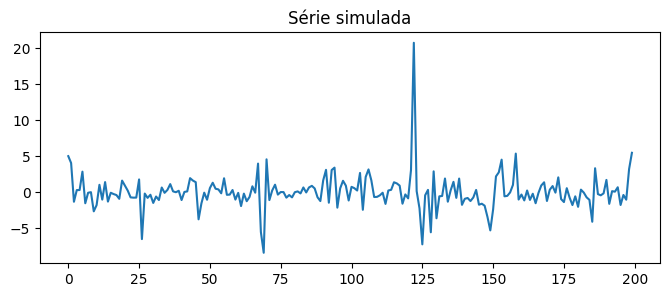

In [9]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(series)), series)
ax.set_title('Série simulada')
plt.show()

## 2) Simulação da densidade preditiva

### i) k=3

In [10]:
k = 3
σ2_error = ν/(ν-2)

y_hat = np.zeros(T+k)

for t in range(T):
    y2_curr = series[t]**2
    
    for i in range(k):
        σ2_hat = ω + α * y2_hat
        y2_curr = σ2_hat * σ2_error

    y_hat[t+k] = y2_curr**0.5

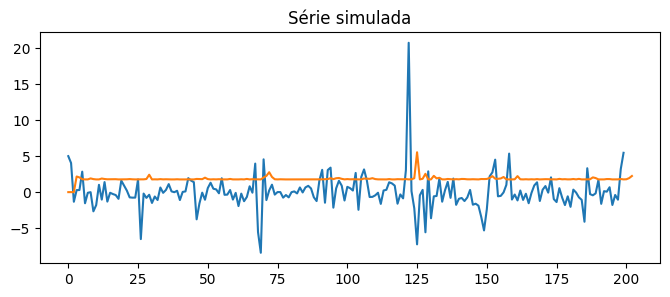

In [11]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(series)), series)
ax.plot(np.arange(len(y_hat)), y_hat)
ax.set_title('Série simulada')
plt.show()

### ii) k=30